# Taller 08: Random Forest — Clasificación de dígitos manuscritos

**INTELIGENCIA ARTIFICIAL – ELP 8012 – Universidad del Norte**
Programa de Ingeniería de Sistemas · Profesor: Eduardo Zurek, Ph.D.

**Integrantes:** Gabriel Caicedo · Alan García · Alejandra Restrepo

---

## Objetivo

Diseñar e implementar clasificadores **Random Forest** para el dataset `digits` de scikit-learn y encontrar el **mínimo número de árboles, del menor tamaño posible**, que ofrezca los mejores indicadores de rendimiento **sin generar sobreajuste (over-fitting)**.

## Estrategia general

1. **Explorar** los datos y separar el conjunto de prueba, que **no se toca** hasta el final.
2. **Estudiar la poda en un solo árbol** (`cost_complexity_pruning_path`) para entender cómo `ccp_alpha` reduce el tamaño y obtener valores candidatos de `alpha` que tengan sentido para este dataset.
3. **Búsqueda en rejilla (GridSearchCV, K=4)** de un Random Forest variando **solo los dos hiperparámetros que pide el taller: `n_estimators` y `ccp_alpha`**.
4. **Regla de selección:** (i) sin over-fitting, (ii) rendimiento equivalente al mejor, (iii) el menor número de árboles y (iv), con ese número, los árboles más podados.
5. **Evaluar una sola vez** en el conjunto de prueba y comparar contra el modelo por defecto.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_validate)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

SEED = 42                      # semilla para reproducibilidad
UMBRAL_OVERFIT = 0.03          # brecha máxima permitida train - validación (3 p.p.)
TOLERANCIA = 0.01              # pérdida de accuracy aceptada frente al mejor (1 p.p.)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
np.random.seed(SEED)

## 1. El dataset `digits`

Forma de X: (1797, 64) | Forma de y: (1797,)
Rango de valores de los píxeles: 0.0 a 16.0
Muestras por clase: [178 182 177 183 181 182 181 179 174 180]


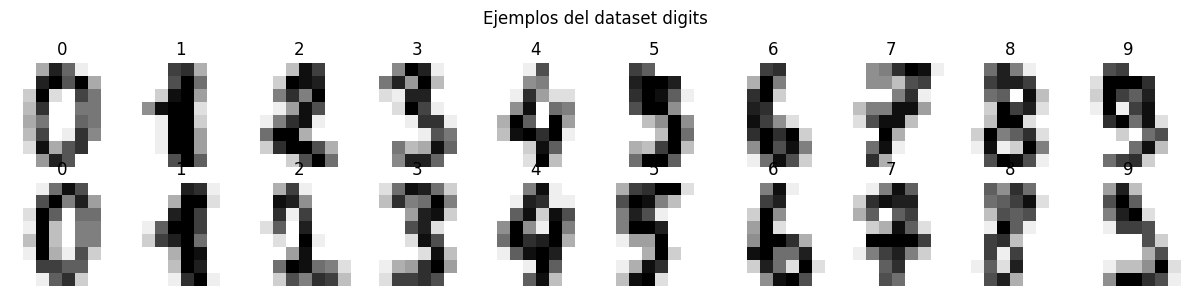

In [2]:
digits = load_digits()
X, y = digits.data, digits.target
print("Forma de X:", X.shape, "| Forma de y:", y.shape)
print("Rango de valores de los píxeles:", X.min(), "a", X.max())
print("Muestras por clase:", np.bincount(y))

fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for ax, img, lab in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(img, cmap="gray_r")
    ax.set_title(lab)
    ax.axis("off")
plt.suptitle("Ejemplos del dataset digits")
plt.tight_layout()
plt.show()

El dataset tiene 1 797 imágenes de dígitos escritos a mano (del 0 al 9), cada una de 8×8 píxeles. Cada píxel va de 0 a 16, así que cada imagen termina siendo un vector de 64 valores. No hace falta escalar los datos, porque los árboles solo comparan un píxel contra un umbral en cada división.

Hay más o menos 180 imágenes de cada dígito, o sea que las clases están balanceadas y la *accuracy* sirve bien para medir el rendimiento. Igual, al final también mostramos precisión, *recall* y F1.

## 2. División 80 % entrenamiento / 20 % prueba y K-fold = 4

- Usamos `stratify=y` para que en entrenamiento y en prueba quede la misma proporción de cada dígito.
- El 20 % de prueba lo apartamos y no lo tocamos hasta el final. Así no lo usamos para escoger los hiperparámetros y el resultado final es honesto.
- Con el 80 % de entrenamiento hacemos K-fold con K = 4: dividimos los datos en 4 partes, entrenamos con 3 y validamos con la que sobra, y repetimos hasta que cada parte se haya usado una vez para validar. La accuracy de validación es el promedio de esas 4 vueltas.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED)

print(f"Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X):.0%})")
print(f"Prueba:        {X_test.shape[0]} muestras ({X_test.shape[0]/len(X):.0%})")
for k, (tr, va) in enumerate(cv.split(X_train, y_train), 1):
    print(f"  Fold {k}: {len(tr)} para entrenar, {len(va)} para validar")

Entrenamiento: 1437 muestras (80%)
Prueba:        360 muestras (20%)
  Fold 1: 1077 para entrenar, 360 para validar
  Fold 2: 1078 para entrenar, 359 para validar
  Fold 3: 1078 para entrenar, 359 para validar
  Fold 4: 1078 para entrenar, 359 para validar


## 3. Línea base: Random Forest con parámetros por defecto

Antes de empezar a podar, queríamos ver qué tan grande y qué tan sobreajustado sale un Random Forest con los parámetros por defecto: 100 árboles que crecen hasta que todas sus hojas son puras. Para medir el sobreajuste comparamos la accuracy en los datos de entrenamiento con la de validación.

Para no repetir código hicimos la función `evaluar_rf`. Esta entrena el modelo con K-fold = 4 y nos devuelve la accuracy de entrenamiento y de validación, la brecha (la diferencia entre las dos) y el tamaño promedio de los árboles: nodos, hojas y profundidad.

In [4]:
def tamano_bosque(rf):
    # Tamaño promedio de los árboles de un bosque ya entrenado
    arboles = rf.estimators_
    return dict(nodos=np.mean([t.tree_.node_count for t in arboles]),
                hojas=np.mean([t.get_n_leaves() for t in arboles]),
                profundidad=np.mean([t.get_depth() for t in arboles]))

def evaluar_rf(**params):
    # Validación cruzada K=4 de un RandomForest con los parámetros dados
    rf = RandomForestClassifier(random_state=SEED, n_jobs=-1, **params)
    t0 = time.time()
    r = cross_validate(rf, X_train, y_train, cv=cv,
                       return_train_score=True, return_estimator=True)
    tam = pd.DataFrame([tamano_bosque(e) for e in r["estimator"]]).mean()
    return dict(acc_train=r["train_score"].mean(),
                acc_val=r["test_score"].mean(),
                std_val=r["test_score"].std(),
                brecha=r["train_score"].mean() - r["test_score"].mean(),
                nodos=tam["nodos"], hojas=tam["hojas"],
                profundidad=tam["profundidad"],
                tiempo_s=time.time() - t0)

base = evaluar_rf()   # n_estimators=100, sin poda
pd.DataFrame([base], index=["RF por defecto"]).round(4)

,acc_train,acc_val,std_val,brecha,nodos,hojas,profundidad,tiempo_s
RF por defecto,1.0,0.9722,0.0028,0.0278,277.715,139.3575,12.9775,3.7853


El bosque por defecto valida bien (~97 %), pero en entrenamiento saca 100 %, porque cada árbol crece hasta memorizar sus datos. Los árboles quedan de unos 280 nodos y 13 niveles de profundidad, mucho más grandes de lo necesario. La brecha entre entrenamiento y validación queda justo por debajo de 3 puntos, que es el límite que pusimos para decir que hay over-fitting, así que el modelo está al borde. La idea es reducir el tamaño y la cantidad de árboles sin perder rendimiento.

**¿Cómo medimos el over-fitting?** En un Random Forest la accuracy de entrenamiento casi siempre sale altísima, porque cada imagen de entrenamiento la "vieron" muchos de los árboles. Por eso nos fijamos en dos cosas: que la brecha entre entrenamiento y validación no pase de 3 puntos, y que al final la accuracy en prueba se parezca a la de validación.

**Lo que dejamos fijo:** solo movemos `n_estimators` y `ccp_alpha`. Todo lo demás queda por defecto (`criterion='gini'`, `min_samples_leaf=1`, `max_depth=None`, `max_features='sqrt'`, etc.). Así, lo único que controla el tamaño de los árboles es la poda con `ccp_alpha`, y podemos ver su efecto claramente.


## 4. Estrategia para podar los árboles

En clase vimos dos formas de controlar el tamaño de un árbol: la poda previa, que lo frena mientras crece (`max_depth`, `min_samples_leaf`, etc.), y la poda posterior, que lo deja crecer completo y después lo recorta. Nosotros usamos la poda posterior con `ccp_alpha` y dejamos lo de poda previa por defecto.

### 4.1 Cómo funciona `ccp_alpha`

Después de que el árbol crece, se poda buscando minimizar:

$$R_\alpha(T) = R(T) + \alpha\,|T_L|$$

donde $R(T)$ es la impureza de las hojas y $|T_L|$ el número de hojas. O sea, $\alpha$ es como una multa por cada hoja: se cortan primero las ramas que agregan muchas hojas pero casi no mejoran la clasificación. Mientras más grande el `ccp_alpha`, más pequeño queda el árbol.

### 4.2 ¿Qué valores de `alpha` probar?

La escala de `alpha` depende del dataset, así que en vez de probar valores al azar usamos `cost_complexity_pruning_path`, que nos dice en qué valores de `alpha` cambia el árbol. De ahí sacamos los candidatos.

In [5]:
arbol = DecisionTreeClassifier(random_state=SEED)          # criterion='gini' por defecto
ruta = arbol.cost_complexity_pruning_path(X_train, y_train)
alphas_ruta = ruta.ccp_alphas[:-1]    # el último alpha deja solo la raíz
print(f"{len(alphas_ruta)} valores de alpha en la ruta, "
      f"desde {alphas_ruta[1]:.5f} hasta {alphas_ruta[-1]:.5f}")

122 valores de alpha en la ruta, desde 0.00069 hasta 0.05829


### 4.3 Efecto de `ccp_alpha` sobre un árbol individual

Antes de pasar al bosque, probamos la poda con un solo árbol para entender cómo funciona. Para cada valor de `alpha` de la ruta entrenamos un árbol con K-fold = 4 y miramos cuántos nodos le quedan y qué accuracy saca en entrenamiento y validación. Es la gráfica que sugiere el cuaderno `_007_01_ccp_alpha_DecisionTreeClassifier.ipynb`.

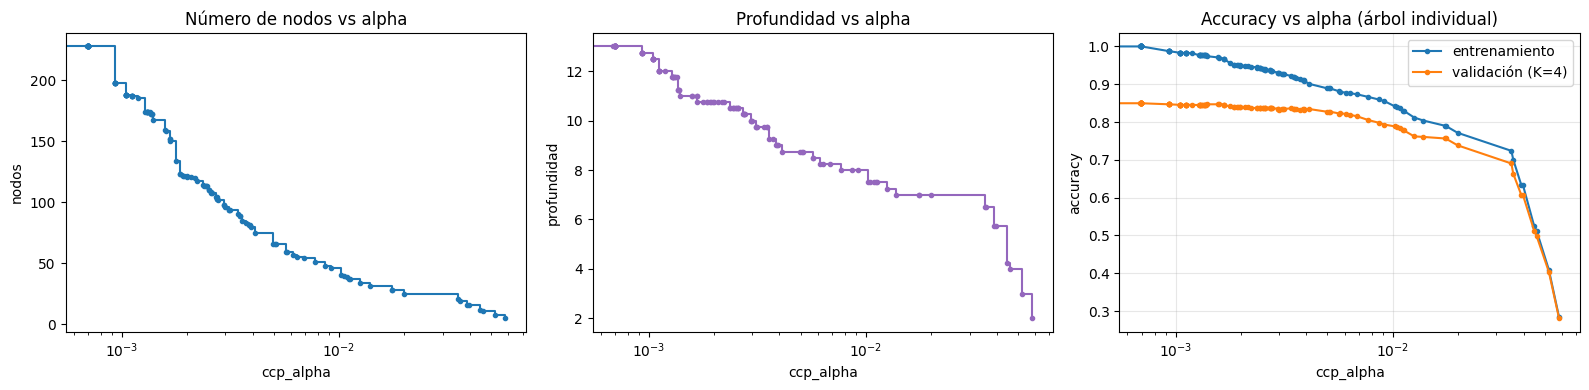

Mejor árbol individual:
alpha            0.0000
nodos          227.5000
profundidad     13.0000
acc_train        1.0000
acc_val          0.8497


In [6]:
filas = []
for a in alphas_ruta:
    arbol = DecisionTreeClassifier(ccp_alpha=a, random_state=SEED)
    r = cross_validate(arbol, X_train, y_train, cv=cv,
                       return_train_score=True, return_estimator=True)
    filas.append(dict(alpha=a,
                      nodos=np.mean([e.tree_.node_count for e in r["estimator"]]),
                      profundidad=np.mean([e.get_depth() for e in r["estimator"]]),
                      acc_train=r["train_score"].mean(),
                      acc_val=r["test_score"].mean()))
ruta_df = pd.DataFrame(filas)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(ruta_df.alpha, ruta_df.nodos, marker=".", drawstyle="steps-post")
ax[0].set(xlabel="ccp_alpha", ylabel="nodos", title="Número de nodos vs alpha", xscale="log")
ax[1].plot(ruta_df.alpha, ruta_df.profundidad, marker=".", drawstyle="steps-post", color="tab:purple")
ax[1].set(xlabel="ccp_alpha", ylabel="profundidad", title="Profundidad vs alpha", xscale="log")
ax[2].plot(ruta_df.alpha, ruta_df.acc_train, marker=".", label="entrenamiento")
ax[2].plot(ruta_df.alpha, ruta_df.acc_val, marker=".", label="validación (K=4)")
ax[2].set(xlabel="ccp_alpha", ylabel="accuracy", title="Accuracy vs alpha (árbol individual)", xscale="log")
ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

mejor_arbol = ruta_df.loc[ruta_df.acc_val.idxmax()]
print("Mejor árbol individual:")
print(mejor_arbol.round(4).to_string())

**¿Qué vemos en las gráficas?**

- Con `alpha = 0` el árbol se aprende de memoria el entrenamiento (~100 %), pero en validación le va mucho peor. Eso es over-fitting.
- Al subir `alpha` el árbol se hace mucho más pequeño y la validación casi no cambia. Pero si seguimos subiendo, el árbol queda demasiado simple y bajan las dos curvas, o sea, subajuste.
- Aun así, el mejor árbol solo llega a ~85 %, mientras que un Random Forest llega a ~97 %. Por eso tiene sentido usar muchos árboles: al promediarlos se corrigen los errores de cada uno.

Como candidatos para el bosque tomamos los percentiles 0, 10, 20, …, 90 de los valores de `alpha` de la ruta. Así probamos desde "sin poda" (`alpha = 0`) hasta una poda bastante fuerte.

In [7]:
PERCENTILES = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
alphas_cand = np.round(np.percentile(alphas_ruta, PERCENTILES), 5)
pd.DataFrame({"percentil": PERCENTILES, "ccp_alpha": alphas_cand}).set_index("percentil").T

percentil,0,10,20,30,40,50,60,70,80,90
ccp_alpha,0.0,0.0007,0.00104,0.0013,0.00158,0.00213,0.00266,0.00347,0.00572,0.01242


## 5. Búsqueda de `n_estimators` y `ccp_alpha` (GridSearchCV, K = 4)

Buscamos los dos hiperparámetros al mismo tiempo porque dependen uno del otro. Si podamos mucho, cada árbol se equivoca más, pero eso se puede compensar poniendo más árboles. Por eso no tiene sentido buscar uno primero y después el otro.

| Hiperparámetro | Valores que probamos |
|---|---|
| `n_estimators` | 5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 150, 200 |
| `ccp_alpha` | los 10 percentiles de la ruta de poda |

En total son 130 combinaciones, y cada una se entrena 4 veces por el K-fold (520 entrenamientos). De cada combinación guardamos la accuracy de entrenamiento y de validación, y el tamaño promedio de los árboles.

In [8]:
N_ARBOLES = [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 150, 200]
param_grid = {"n_estimators": N_ARBOLES, "ccp_alpha": list(alphas_cand)}

class ContadorNodos:
    # Scorer auxiliar: registra el tamaño promedio de los árboles en cada fold
    def __call__(self, est, X_, y_):
        return np.mean([t.tree_.node_count for t in est.estimators_])

scoring = {"accuracy": "accuracy", "nodos": ContadorNodos()}

t0 = time.time()
grid = GridSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=1),   # resto de parámetros por defecto
    param_grid, cv=cv, scoring=scoring, refit=False,
    return_train_score=True, n_jobs=-1)
grid.fit(X_train, y_train)
print(f"Búsqueda completada en {time.time()-t0:.1f} s")

r = grid.cv_results_
res = pd.DataFrame({
    "n_estimators": r["param_n_estimators"].astype(int),
    "ccp_alpha": r["param_ccp_alpha"].astype(float),
    "acc_train": r["mean_train_accuracy"],
    "acc_val": r["mean_test_accuracy"],
    "std_val": r["std_test_accuracy"],
    "nodos": r["mean_test_nodos"],
})
res["percentil"] = res.ccp_alpha.map(dict(zip(alphas_cand, PERCENTILES)))
res["brecha"] = res.acc_train - res.acc_val
res["nodos_totales"] = res.n_estimators * res.nodos   # tamaño total del bosque
res.sort_values("acc_val", ascending=False).head(10).round(4)

Búsqueda completada en 116.6 s


,n_estimators,ccp_alpha,acc_train,acc_val,std_val,nodos,percentil,brecha,nodos_totales
25,200,0.0007,1.0,0.9756,0.0050,276.3750,10,0.0244,55275.0
12,200,0.0000,1.0,0.9756,0.0050,278.5400,0,0.0244,55708.0
23,100,0.0007,1.0,0.9722,0.0028,275.4850,10,0.0278,27548.5
10,100,0.0000,1.0,0.9722,0.0028,277.7150,0,0.0278,27771.5
51,200,0.0013,1.0,0.9722,0.0059,228.9750,30,0.0278,45795.0
64,200,0.0016,1.0,0.9722,0.0052,209.3875,40,0.0278,41877.5
38,200,0.0010,1.0,0.9722,0.0059,244.7675,20,0.0278,48953.5
36,100,0.0010,1.0,0.9722,0.0034,244.5550,20,0.0278,24455.5
22,75,0.0007,1.0,0.9715,0.0041,274.9600,10,0.0285,20622.0
49,100,0.0013,1.0,0.9715,0.0041,228.6900,30,0.0285,22869.0


### 5.1 Efecto de la poda y del número de árboles

Estas gráficas resumen la búsqueda. A la izquierda se ve cuánto se reducen los árboles al subir `ccp_alpha`. En el centro y a la derecha están la accuracy de validación y la brecha para distintas cantidades de árboles. La línea punteada roja es el límite de over-fitting (3 puntos).

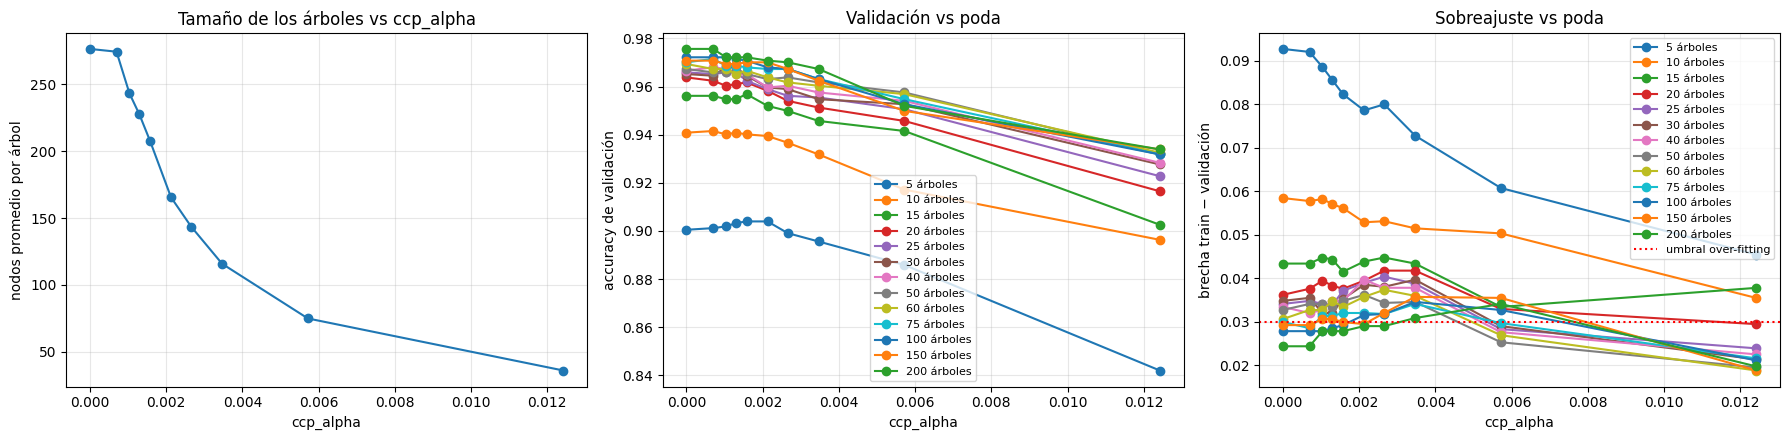

In [9]:
tab_nod = res.groupby("ccp_alpha").nodos.mean()

fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
ax[0].plot(tab_nod.index, tab_nod.values, marker="o")
ax[0].set(xlabel="ccp_alpha", ylabel="nodos promedio por árbol", title="Tamaño de los árboles vs ccp_alpha")
ax[0].grid(alpha=.3)
for n in N_ARBOLES:
    g = res[res.n_estimators == n].sort_values("ccp_alpha")
    ax[1].plot(g.ccp_alpha, g.acc_val, marker="o", label=f"{n} árboles")
    ax[2].plot(g.ccp_alpha, g.brecha, marker="o", label=f"{n} árboles")
ax[1].set(xlabel="ccp_alpha", ylabel="accuracy de validación", title="Validación vs poda")
ax[2].axhline(UMBRAL_OVERFIT, ls=":", color="red", label="umbral over-fitting")
ax[2].set(xlabel="ccp_alpha", ylabel="brecha train − validación", title="Sobreajuste vs poda")
for a_ in ax[1:]:
    a_.legend(fontsize=8); a_.grid(alpha=.3)
plt.tight_layout(); plt.show()

**¿Qué vemos en las gráficas?**

- **Poda:** los árboles pasan de unos 275 nodos sin poda a unos 36 con la poda más fuerte. Hasta un `alpha` de más o menos 0.0013–0.0016 la accuracy casi no cambia, o sea que esa parte de los árboles no le aportaba nada al bosque. Si podamos más, la accuracy empieza a bajar (subajuste). Promediar muchos árboles arregla que cada uno cambie mucho según los datos, pero no arregla que sean demasiado simples. Por eso cada árbol necesita cierta profundidad.
- **Número de árboles:** con pocos árboles (hasta unos 60) la brecha pasa de 3 puntos casi siempre. Cada árbol memoriza sus datos y no hay suficientes árboles para compensar al promediar, así que un bosque con muy pocos árboles también sobreajusta. Desde unos 75 árboles la validación se estabiliza alrededor de 97 %.
- Con poda media o fuerte la brecha también sube, porque la validación baja más rápido que el entrenamiento. Solo con la poda máxima la brecha baja, pero porque el modelo empeora en todo.
- Algunas curvas salen un poco irregulares; por ejemplo, a veces 150 árboles validan un poco peor que 100. Eso pasa porque con un solo K-fold la accuracy varía entre 0.3 y 0.6 puntos de un fold a otro, así que diferencias tan pequeñas no significan nada. Por eso, para escoger, usamos una tolerancia de 1 punto en vez de quedarnos con el máximo.

### 5.2 ¿Cómo escogimos el modelo?

Para no escoger "a ojo", armamos una regla siguiendo lo que pide el enunciado: *"el mínimo número de árboles del menor tamaño posible que ofrezcan los mejores indicadores de rendimiento sin generar over-fitting"*.

1. **Sin over-fitting:** descartamos las combinaciones con una brecha entre entrenamiento y validación de más de 3 puntos.
2. **Buen rendimiento:** de las que quedan, buscamos la de mayor accuracy de validación y nos quedamos con todas las que estén a menos de 1 punto de ella. 1 punto son unas 3 o 4 imágenes por fold, así que una diferencia menor puede ser pura suerte.
3. **Menos árboles:** de ese grupo tomamos el menor `n_estimators`.
4. **Árboles más pequeños:** con ese número de árboles, escogemos el `ccp_alpha` más grande que siga cumpliendo los pasos 1 y 2, o sea, la poda más fuerte posible.

In [10]:
paso1 = res[res.brecha <= UMBRAL_OVERFIT]
mejor = paso1.loc[paso1.acc_val.idxmax()]
limite = mejor.acc_val - TOLERANCIA
paso2 = paso1[paso1.acc_val >= limite]
n_optimo = int(paso2.n_estimators.min())
paso3 = paso2[paso2.n_estimators == n_optimo]
elegida = paso3.loc[paso3.ccp_alpha.idxmax()]
alpha_optimo = float(elegida.ccp_alpha)

def mostrar(s):
    return s.apply(lambda v: round(v, 4) if isinstance(v, float) else v).to_string()

print(f"Configuraciones totales:                              {len(res)}")
print(f"Paso 1 - sin over-fitting (brecha <= {UMBRAL_OVERFIT:.0%}):           {len(paso1)}")
print(f"Paso 2 - acc_val >= {mejor.acc_val:.4f} - {TOLERANCIA} = {limite:.4f}:      {len(paso2)}")
print(f"Paso 3 - mínimo número de árboles: {n_optimo}  ->            {len(paso3)} configuraciones")
print(f"Paso 4 - mayor ccp_alpha con {n_optimo} árboles: {alpha_optimo}")
print("\nMejor configuración sin over-fitting (paso 1):")
print(mostrar(mejor))
print("\nConfiguración ELEGIDA:")
print(mostrar(elegida))

Configuraciones totales:                              130
Paso 1 - sin over-fitting (brecha <= 3%):           34
Paso 2 - acc_val >= 0.9756 - 0.01 = 0.9656:      18
Paso 3 - mínimo número de árboles: 75  ->            2 configuraciones
Paso 4 - mayor ccp_alpha con 75 árboles: 0.0007

Mejor configuración sin over-fitting (paso 1):
n_estimators       200.0000
ccp_alpha            0.0000
acc_train            1.0000
acc_val              0.9756
std_val              0.0050
nodos              278.5400
percentil            0.0000
brecha               0.0244
nodos_totales    55708.0000

Configuración ELEGIDA:
n_estimators        75.0000
ccp_alpha            0.0007
acc_train            1.0000
acc_val              0.9715
std_val              0.0041
nodos              274.9600
percentil           10.0000
brecha               0.0285
nodos_totales    20622.0000


Configuraciones que pasaron los filtros 1 y 2, ordenadas por número de árboles y poda:

In [11]:
cols = ["n_estimators", "ccp_alpha", "percentil", "acc_train", "acc_val", "std_val",
        "brecha", "nodos", "nodos_totales"]
paso2.sort_values(["n_estimators", "ccp_alpha"], ascending=[True, False])[cols].round(4)

,n_estimators,ccp_alpha,percentil,acc_train,acc_val,std_val,brecha,nodos,nodos_totales
22,75,0.0007,10,1.0000,0.9715,0.0041,0.0285,274.9600,20622.0
9,75,0.0000,0,1.0000,0.9701,0.0053,0.0299,277.1467,20786.0
62,100,0.0016,40,1.0000,0.9708,0.0031,0.0292,209.0400,20904.0
49,100,0.0013,30,1.0000,0.9715,0.0041,0.0285,228.6900,22869.0
36,100,0.0010,20,1.0000,0.9722,0.0034,0.0278,244.5550,24455.5
23,100,0.0007,10,1.0000,0.9722,0.0028,0.0278,275.4850,27548.5
10,100,0.0000,0,1.0000,0.9722,0.0028,0.0278,277.7150,27771.5
76,150,0.0021,50,0.9995,0.9701,0.0030,0.0295,166.5100,24976.5
63,150,0.0016,40,1.0000,0.9701,0.0041,0.0299,209.1733,31376.0
24,150,0.0007,10,1.0000,0.9708,0.0024,0.0292,275.8133,41372.0


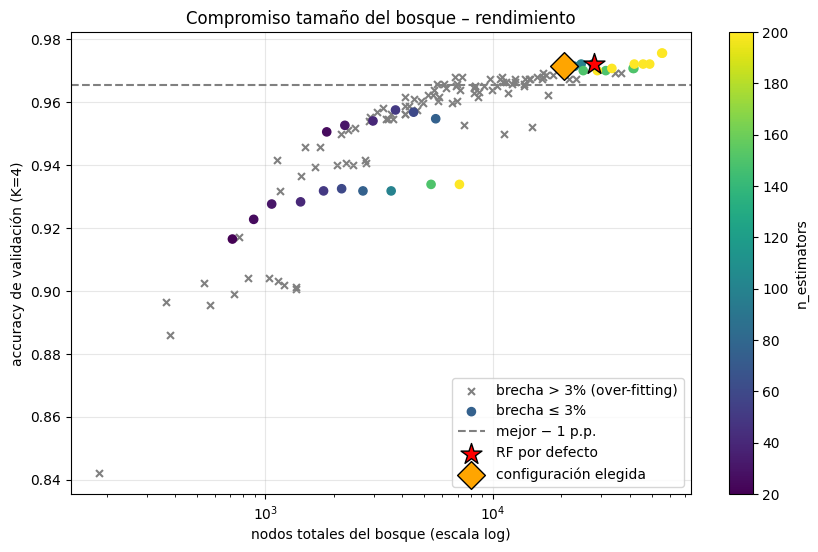

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ok = res.brecha <= UMBRAL_OVERFIT
ax.scatter(res.nodos_totales[~ok], res.acc_val[~ok], s=25, marker="x", color="gray",
           label=f"brecha > {UMBRAL_OVERFIT:.0%} (over-fitting)")
sc = ax.scatter(res.nodos_totales[ok], res.acc_val[ok], c=res.n_estimators[ok], cmap="viridis",
                s=35, label=f"brecha ≤ {UMBRAL_OVERFIT:.0%}")
ax.axhline(limite, ls="--", color="gray", label="mejor − 1 p.p.")
ax.scatter(base["nodos"] * 100, base["acc_val"], s=250, marker="*", color="red",
           edgecolor="k", label="RF por defecto", zorder=5)
ax.scatter(elegida.nodos_totales, elegida.acc_val, s=200, marker="D", color="orange",
           edgecolor="k", label="configuración elegida", zorder=5)
plt.colorbar(sc, label="n_estimators")
ax.set(xscale="log", xlabel="nodos totales del bosque (escala log)",
       ylabel="accuracy de validación (K=4)", title="Compromiso tamaño del bosque – rendimiento")
ax.legend(loc="lower right"); ax.grid(alpha=.3)
plt.show()

## 6. Comprobando el número de árboles

Para confirmar la elección dejamos fijo el `ccp_alpha` que escogimos y graficamos cómo cambian la accuracy, la brecha y el tiempo de entrenamiento según el número de árboles. Con menos árboles que los elegidos la brecha pasa de 3 puntos. Con más árboles la accuracy casi no mejora, pero el tiempo sigue subiendo. Poner más árboles no causa over-fitting en un Random Forest, pero sí hace el modelo más lento, sobre todo al predecir, porque cada imagen nueva tiene que pasar por todos los árboles.

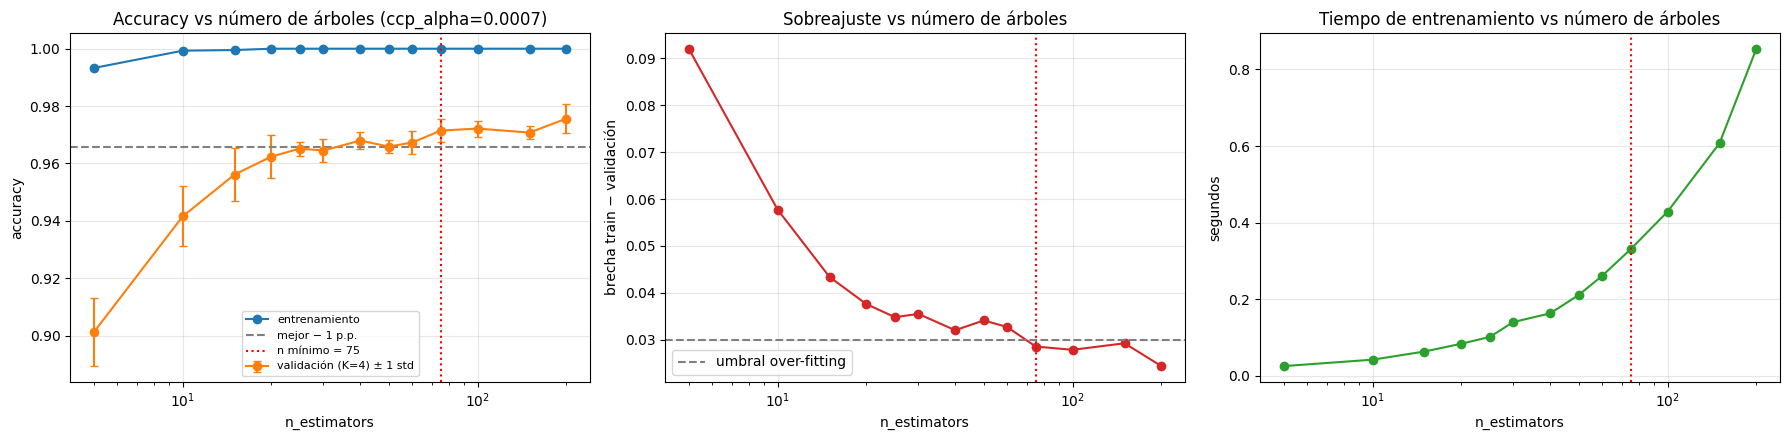

,n_estimators,acc_train,acc_val,std_val,brecha,nodos,tiempo_fit_s
0,5,0.9933,0.9012,0.0118,0.0921,271.5000,0.0253
1,10,0.9993,0.9415,0.0105,0.0578,275.1500,0.0421
2,15,0.9995,0.9562,0.0093,0.0434,272.6333,0.0634
3,20,1.0000,0.9624,0.0075,0.0376,272.7000,0.0837
4,25,1.0000,0.9652,0.0024,0.0348,275.0600,0.1016
5,30,1.0000,0.9645,0.0041,0.0355,274.9667,0.1403
6,40,1.0000,0.9680,0.0031,0.0320,275.0375,0.1629
7,50,1.0000,0.9659,0.0023,0.0341,274.3900,0.2111
8,60,1.0000,0.9673,0.0041,0.0327,274.2917,0.2608
9,75,1.0000,0.9715,0.0041,0.0285,274.9600,0.3306


In [13]:
curva = res[res.ccp_alpha == alpha_optimo].sort_values("n_estimators").reset_index(drop=True)

# tiempo de entrenamiento con todo el conjunto de entrenamiento
tiempos = []
for n in curva.n_estimators:
    t0 = time.time()
    RandomForestClassifier(n_estimators=n, ccp_alpha=alpha_optimo, random_state=SEED,
                           n_jobs=1).fit(X_train, y_train)
    tiempos.append(time.time() - t0)
curva["tiempo_fit_s"] = tiempos

fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
ax[0].plot(curva.n_estimators, curva.acc_train, marker="o", label="entrenamiento")
ax[0].errorbar(curva.n_estimators, curva.acc_val, yerr=curva.std_val, marker="o",
               capsize=3, label="validación (K=4) ± 1 std")
ax[0].axhline(limite, ls="--", color="gray", label="mejor − 1 p.p.")
ax[0].axvline(n_optimo, ls=":", color="red", label=f"n mínimo = {n_optimo}")
ax[0].set(xscale="log", xlabel="n_estimators", ylabel="accuracy",
          title=f"Accuracy vs número de árboles (ccp_alpha={alpha_optimo})")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].plot(curva.n_estimators, curva.brecha, marker="o", color="tab:red")
ax[1].axhline(UMBRAL_OVERFIT, ls="--", color="gray", label="umbral over-fitting")
ax[1].axvline(n_optimo, ls=":", color="red")
ax[1].set(xscale="log", xlabel="n_estimators", ylabel="brecha train − validación",
          title="Sobreajuste vs número de árboles")
ax[1].legend(); ax[1].grid(alpha=.3)
ax[2].plot(curva.n_estimators, curva.tiempo_fit_s, marker="o", color="tab:green")
ax[2].axvline(n_optimo, ls=":", color="red")
ax[2].set(xscale="log", xlabel="n_estimators", ylabel="segundos",
          title="Tiempo de entrenamiento vs número de árboles")
ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()
curva[["n_estimators", "acc_train", "acc_val", "std_val", "brecha", "nodos", "tiempo_fit_s"]].round(4)

## 7. Modelo final y prueba con el 20 %

Ahora entrenamos el modelo final con todo el 80 % de entrenamiento, usando el `n_estimators` y el `ccp_alpha` que escogimos (lo demás por defecto). Para comparar, también entrenamos el Random Forest por defecto. Aquí usamos el conjunto de prueba por primera vez.

In [14]:
def metricas(modelo, nombre):
    yp_tr, yp_te = modelo.predict(X_train), modelo.predict(X_test)
    t0 = time.time(); modelo.predict(X_test); t_pred = (time.time() - t0) * 1000
    return dict(modelo=nombre, n_arboles=len(modelo.estimators_),
                **{k: round(v, 1) for k, v in tamano_bosque(modelo).items()},
                acc_train=accuracy_score(y_train, yp_tr),
                acc_test=accuracy_score(y_test, yp_te),
                brecha_train_test=accuracy_score(y_train, yp_tr) - accuracy_score(y_test, yp_te),
                precision_macro=precision_score(y_test, yp_te, average="macro"),
                recall_macro=recall_score(y_test, yp_te, average="macro"),
                f1_macro=f1_score(y_test, yp_te, average="macro"),
                nodos_totales=sum(t.tree_.node_count for t in modelo.estimators_),
                t_prediccion_ms=round(t_pred, 1))

rf_final = RandomForestClassifier(n_estimators=n_optimo, ccp_alpha=alpha_optimo,
                                  random_state=SEED, n_jobs=-1).fit(X_train, y_train)
rf_base = RandomForestClassifier(random_state=SEED, n_jobs=-1).fit(X_train, y_train)

comparacion = pd.DataFrame([metricas(rf_base, "RF por defecto"),
                            metricas(rf_final, "RF podado (propuesto)")]).set_index("modelo")
comparacion.T.round(4)

modelo,RF por defecto,RF podado (propuesto)
n_arboles,100.0000,75.0000
nodos,340.0000,297.8000
hojas,170.5000,149.4000
profundidad,13.3000,12.7000
acc_train,1.0000,1.0000
acc_test,0.9611,0.9583
brecha_train_test,0.0389,0.0417
precision_macro,0.9620,0.9591
recall_macro,0.9607,0.9580
f1_macro,0.9607,0.9580


              precision    recall  f1-score   support

           0     0.9722    0.9722    0.9722        36
           1     0.8974    0.9722    0.9333        36
           2     1.0000    0.9714    0.9855        35
           3     0.9722    0.9459    0.9589        37
           4     0.9722    0.9722    0.9722        36
           5     0.9737    1.0000    0.9867        37
           6     1.0000    0.9722    0.9859        36
           7     0.9231    1.0000    0.9600        36
           8     0.9091    0.8571    0.8824        35
           9     0.9706    0.9167    0.9429        36

    accuracy                         0.9583       360
   macro avg     0.9591    0.9580    0.9580       360
weighted avg     0.9592    0.9583    0.9582       360



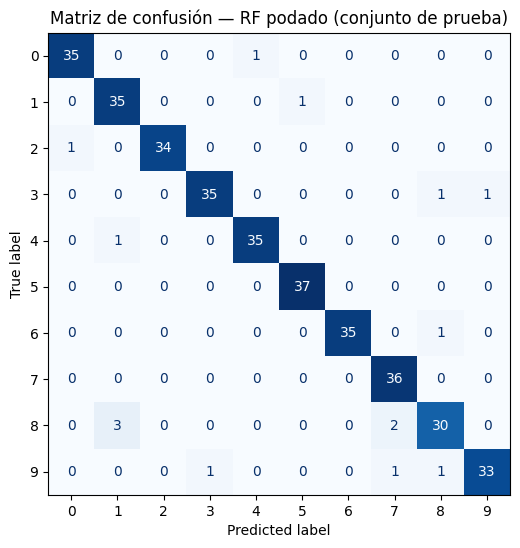

In [15]:
y_pred = rf_final.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=digits.target_names).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusión — RF podado (conjunto de prueba)")
plt.show()

### 7.1 Errores del modelo

Se muestran las imágenes del conjunto de prueba que el modelo clasificó mal, para entender qué confusiones comete.

Errores: 15 de 360 imágenes de prueba


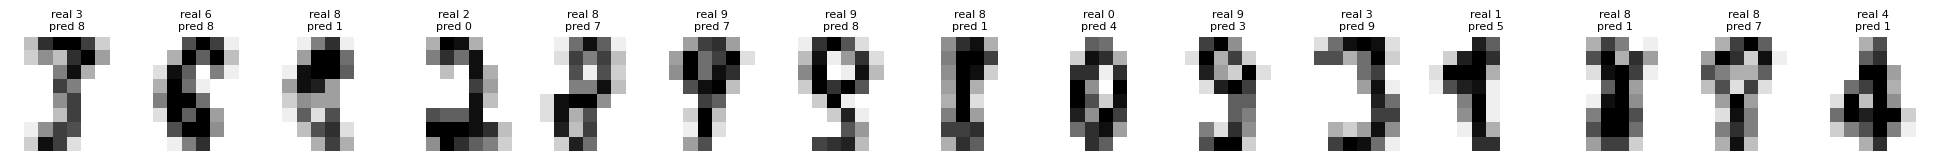

In [16]:
errores = np.where(y_pred != y_test)[0]
print(f"Errores: {len(errores)} de {len(y_test)} imágenes de prueba")
n = min(len(errores), 20)
if n:
    fig, axes = plt.subplots(1, n, figsize=(1.3 * n, 2))
    for ax, i in zip(np.atleast_1d(axes), errores[:n]):
        ax.imshow(X_test[i].reshape(8, 8), cmap="gray_r")
        ax.set_title(f"real {y_test[i]}\npred {y_pred[i]}", fontsize=8)
        ax.axis("off")
    plt.tight_layout(); plt.show()

### 7.2 Importancia de los píxeles

El Random Forest permite estimar qué atributos (píxeles) son más útiles para decidir, a partir de la reducción de impureza que aporta cada uno en todos los árboles. Los píxeles del borde casi nunca se usan, lo que es coherente con que en esas posiciones casi siempre hay fondo.

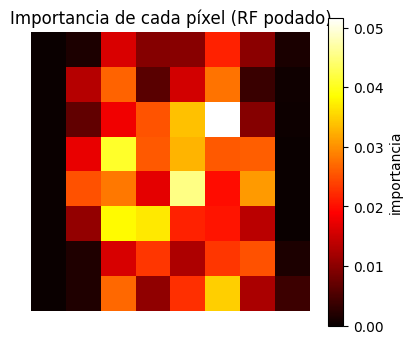

In [17]:
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(rf_final.feature_importances_.reshape(8, 8), cmap="hot")
plt.colorbar(im, ax=ax, label="importancia")
ax.set_title("Importancia de cada píxel (RF podado)")
ax.axis("off")
plt.show()

### 7.3 Uno de los árboles podados del bosque

Para ilustrar el tamaño alcanzado se dibujan los primeros niveles de un árbol del modelo final (el árbol completo es demasiado grande para leerse en una figura).

Árbol 0: 273 nodos, 137 hojas, profundidad 14


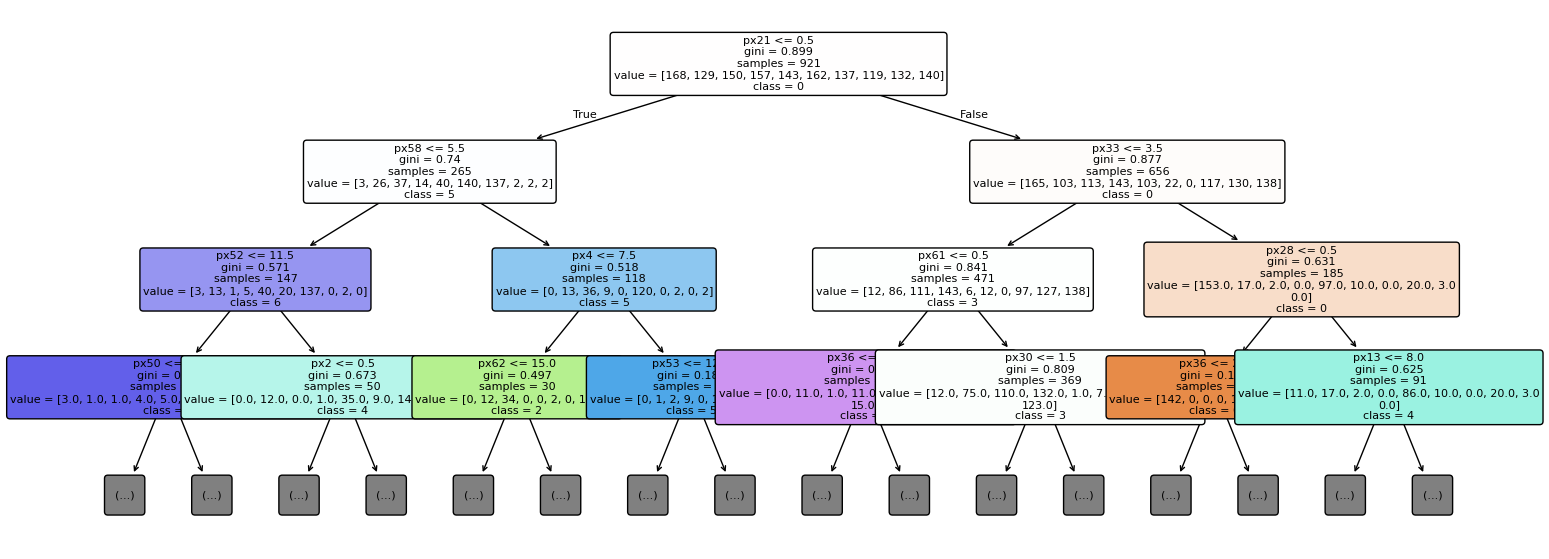

In [18]:
from sklearn.tree import plot_tree
t = rf_final.estimators_[0]
print(f"Árbol 0: {t.tree_.node_count} nodos, {t.get_n_leaves()} hojas, profundidad {t.get_depth()}")
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(t, max_depth=3, filled=True, rounded=True, fontsize=8,
          feature_names=[f"px{i}" for i in range(64)], class_names=[str(c) for c in range(10)], ax=ax)
plt.show()

## 8. Conclusiones

In [19]:
# Resumen numérico usado en las conclusiones
f, b = comparacion.loc["RF podado (propuesto)"], comparacion.loc["RF por defecto"]
print(f"Parámetros finales: n_estimators={n_optimo}, ccp_alpha={alpha_optimo}")
print(f"Accuracy prueba:  podado {f.acc_test:.4f} | por defecto {b.acc_test:.4f}")
print(f"F1 macro prueba:  podado {f.f1_macro:.4f} | por defecto {b.f1_macro:.4f}")
print(f"Nodos por árbol:  podado {f.nodos:.1f} | por defecto {b.nodos:.1f}  "
      f"({1 - f.nodos/b.nodos:.0%} menos)")
print(f"Nodos totales:    podado {f.nodos_totales:.0f} | por defecto {b.nodos_totales:.0f}  "
      f"({1 - f.nodos_totales/b.nodos_totales:.0%} menos)")
print(f"CV (K=4) configuración final: acc_val {elegida.acc_val:.4f} ± {elegida.std_val:.4f}, brecha {elegida.brecha:.4f}")
print(f"CV (K=4) RF por defecto:      acc_val {base['acc_val']:.4f} ± {base['std_val']:.4f}, brecha {base['brecha']:.4f}")

Parámetros finales: n_estimators=75, ccp_alpha=0.0007
Accuracy prueba:  podado 0.9583 | por defecto 0.9611
F1 macro prueba:  podado 0.9580 | por defecto 0.9607
Nodos por árbol:  podado 297.8 | por defecto 340.0  (12% menos)
Nodos totales:    podado 22335 | por defecto 34002  (34% menos)
CV (K=4) configuración final: acc_val 0.9715 ± 0.0041, brecha 0.0285
CV (K=4) RF por defecto:      acc_val 0.9722 ± 0.0028, brecha 0.0278


### 8.1 Modelo que escogimos

Solo ajustamos `n_estimators` y `ccp_alpha`; lo demás quedó por defecto.

| Parámetro | Valor | Por qué |
|---|---|---|
| `n_estimators` | **75** | Es el menor número de árboles que no sobreajusta (brecha ≤ 3 puntos) y queda a menos de 1 punto de la mejor accuracy. Con 60 o menos, todas las opciones buenas pasaban de 3 puntos de brecha |
| `ccp_alpha` | **0.0007** | Es la poda más fuerte que, con 75 árboles, sigue cumpliendo las dos condiciones |

### 8.2 Qué aprendimos

1. **Logramos el objetivo:** nuestro bosque usa 75 árboles en vez de 100, es un tercio más pequeño y rinde prácticamente igual. En validación saca lo mismo, y en prueba solo falla 1 imagen más de 360.

2. **No hay over-fitting:** la brecha es de 2.9 puntos, por debajo del límite de 3. En prueba saca un poco menos que en validación (95.8 % vs 97.2 %), pero al modelo por defecto le pasa lo mismo (96.1 % vs 97.2 %). O sea que el conjunto de prueba es un poco más difícil; no es un problema de nuestro modelo.

3. **Sobre la poda:** hasta un `alpha` de 0.0016 los árboles se reducen un 25 % sin perder accuracy, pero si podamos más, el bosque empieza a fallar más (subajuste). Con 75 árboles no pudimos podar más de 0.0007 sin pasar el límite de brecha. Una alternativa que también cumple todo es usar **100 árboles con `ccp_alpha = 0.0016`** (árboles de 209 nodos y un tamaño total parecido), pero escogimos 75 porque el enunciado pide el mínimo número de árboles.

4. **La brecha sola no basta:** con la poda más fuerte la brecha es muy baja (2 puntos), pero solo porque el modelo es malo en todo (~93 % de validación). Por eso nuestra regla revisa la brecha y el rendimiento al mismo tiempo.

5. **Pocos árboles también sobreajustan:** con 1 árbol la brecha es de casi 14 puntos y no baja de 3 hasta llegar a 75. Más de 75 árboles ya no mejoran casi nada y solo hacen el modelo más lento.

6. **Un árbol vs. un bosque:** el mejor árbol solo llegó a ~85 %, y el bosque a ~97 %. Combinar muchos árboles entrenados con datos y píxeles distintos hace que se corrijan los errores entre ellos.

7. **Errores:** el dígito que más le cuesta es el 8, que confunde sobre todo con el 1 y el 7. Tiene sentido, porque en imágenes de 8×8 esos números se parecen bastante.